# 02 — Data Exploration

**Reproduction of:** Asfaw & Tegaw (2025), *"Explainable machine learning to compare the overall survival status between patients receiving mastectomy and breast conserving surgeries"*, Scientific Reports 15:10700.

## Introduction
This notebook performs the exploratory data analysis (EDA) stage of the reproduction. Before any modelling assumption is made, we need a first-hand, quantitative picture of the METABRIC cohort: its size, its missingness pattern, the balance of the target, and how clinical and molecular variables relate to one another and to the two surgical arms (Mastectomy vs. Breast Conserving Surgery, BCS) that the paper compares.

## Objectives
1. Load the METABRIC clinical data via `src.data_loader` and confirm it matches the paper's stated cohort size (2,509 patients, 34 features).
2. Characterise data types, duplicates, and missingness (reproducing the paper's Table 1).
3. Summarise clinical and molecular variables descriptively, by surgery group.
4. Visualise the target's class balance and the correlation structure of numerical features.
5. Produce publication-quality figures for use in later notebooks and the final report.

## Data source note
The paper cites the Kaggle **"breast-cancer-metabric"** CSV, a flat 34-column export of METABRIC. Our `Data/` folder instead contains the **raw cBioPortal `brca_metabric` study download**, where the same 34 attributes are split across `data_clinical_patient.txt` and `data_clinical_sample.txt`. `src/data_loader.py` merges these two files on `PATIENT_ID` and renames columns to reconstruct the paper's exact feature list (see the module docstring for the one documented substitution: *Mutation Count* → `TMB_NONSYNONYMOUS`, cBioPortal's non-synonymous tumour mutation burden field).

In [1]:
"""Environment setup: make src/ importable and apply the shared plotting style."""
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Nico Personal\master\Health Data Analysis\HDA Final Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import PATHS, set_seeds, TARGET_COL, SURGERY_COL, ID_COL, banner
from src.visualization import set_publication_style, save_figure

set_seeds()
set_publication_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
print(banner("Environment ready"))
print("Project root:", PATHS.root)


============================= Environment ready ==============================
Project root: D:\Nico Personal\master\Health Data Analysis\HDA Final Project


## 1. Loading the raw and modelling-ready cohorts

In [2]:
from src.data_loader import load_raw_clinical, load_clinical, split_by_surgery

raw = load_raw_clinical()
print(f"Raw merged cohort (patient + sample clinical files): {raw.shape[0]} patients x {raw.shape[1]} features")
raw.head()


Raw merged cohort (patient + sample clinical files): 2509 patients x 34 features


,patient_id,lymph_nodes_examined_positive,nottingham_prognostic_index,cellularity,chemotherapy,cohort,er_status_measured_by_ihc,her2_status_measured_by_snp6,hormone_therapy,inferred_menopausal_state,sex,integrative_cluster,age_at_diagnosis,overall_survival_months,overall_survival_status,pam50_claudin_low_subtype,three_gene_classifier_subtype,patients_vital_status,primary_tumor_laterality,radio_therapy,tumor_other_histologic_subtype,type_of_breast_surgery,relapse_free_status_months,relapse_free_status,cancer_type,cancer_type_detailed,er_status,her2_status,neoplasm_histologic_grade,oncotree_code,pr_status,tumor_size,tumor_stage,mutation_count
0,MB-0000,10,6.044,NaN,NO,1,Positve,NEUTRAL,YES,Post,Female,4ER+,75.65,140.5,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.5,0:Not Recurred,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3,IDC,Negative,22,2,0
1,MB-0002,0,4.02,High,NO,1,Positve,NEUTRAL,YES,Pre,Female,4ER+,43.19,84.6333333333333,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.6333333333333,0:Not Recurred,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3,IDC,Positive,10,1,2.615035408
2,MB-0005,1,4.03,High,YES,1,Positve,NEUTRAL,YES,Pre,Female,3,48.87,163.7,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.3,1:Recurred,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,2,IDC,Positive,15,2,2.615035408
3,MB-0006,3,4.05,Moderate,YES,1,Positve,NEUTRAL,YES,Pre,Female,9,47.68,164.933333333333,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333333333,0:Not Recurred,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,2,MDLC,Positive,25,2,1.307517704
4,MB-0008,8,6.08,High,YES,1,Positve,NEUTRAL,YES,Post,Female,9,76.97,41.3666666666667,1:DECEASED,LumB,ER+/HER2- High Prolif,Died of Disease,Right,YES,Mixed,MASTECTOMY,18.8,1:Recurred,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,3,MDLC,Positive,40,2,2.615035408


In [3]:
# Sanity check against the paper: "2509 patients ... 34 columns" (Results & Discussion, p.5)
assert raw.shape == (2509, 34), f"Unexpected shape {raw.shape}, expected (2509, 34) to match the paper"
print("Matches paper cohort size: 2509 patients x 34 features (Patient ID + 33 clinical/molecular attributes).")


Matches paper cohort size: 2509 patients x 34 features (Patient ID + 33 clinical/molecular attributes).


## 2. Data types, duplicates, and structure

The paper reports zero duplicate patient records. We check this directly, and inspect dtypes to distinguish numeric, binary, and multi-category fields.

In [4]:
n_duplicates = raw.duplicated(subset=["patient_id"]).sum()
print(f"Duplicate Patient IDs: {n_duplicates}")

dtype_summary = raw.dtypes.value_counts()
print("\nColumn dtypes:")
print(dtype_summary)

raw.info(memory_usage="deep")


Duplicate Patient IDs: 0

Column dtypes:
object    34
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   patient_id                      2509 non-null   object
 1   lymph_nodes_examined_positive   2243 non-null   object
 2   nottingham_prognostic_index     2287 non-null   object
 3   cellularity                     1917 non-null   object
 4   chemotherapy                    1980 non-null   object
 5   cohort                          2498 non-null   object
 6   er_status_measured_by_ihc       2426 non-null   object
 7   her2_status_measured_by_snp6    1980 non-null   object
 8   hormone_therapy                 1980 non-null   object
 9   inferred_menopausal_state       1980 non-null   object
 10  sex                             2509 non-null   object
 11  integrative_cluster         

## 3. Missing-value pattern (reproduces the paper's Table 1)

In [5]:
from src.preprocessing import missing_value_table

miss_tbl = missing_value_table(raw)
miss_tbl_display = miss_tbl.copy()
miss_tbl_display.index.name = "feature"
miss_tbl_display.to_csv(PATHS.reports / "table1_missing_values_before_imputation.csv")
miss_tbl_display


,n_missing,pct_missing
feature,,
three_gene_classifier_subtype,745,29.69
tumor_stage,721,28.74
primary_tumor_laterality,639,25.47
cellularity,592,23.60
type_of_breast_surgery,554,22.08
pam50_claudin_low_subtype,529,21.08
patients_vital_status,529,21.08
inferred_menopausal_state,529,21.08
hormone_therapy,529,21.08


In [6]:
n_complete_cols = int((miss_tbl["n_missing"] == 0).sum())
n_missing_cols = int((miss_tbl["n_missing"] > 0).sum())
print(f"Columns with 0 missing values: {n_complete_cols}  (paper reports 5)")
print(f"Columns with >0 missing values: {n_missing_cols}  (paper reports 29)")


Columns with 0 missing values: 6  (paper reports 5)
Columns with >0 missing values: 28  (paper reports 29)


**Interpretation.** Our reconstructed dataset shows the same broad missingness pattern the paper describes: a handful of fully-complete columns (identifiers, cancer type, sex, oncotree code) and a larger group of clinical/molecular fields with substantial gaps. The exact per-column counts differ slightly from the paper's Table 1 because we source from the raw cBioPortal export rather than the pre-cleaned Kaggle CSV (see `data_loader.py` docstring) -- the two sources are known to differ marginally in how certain "not assessed" codes are encoded as missing. This is documented further in Notebook 09.

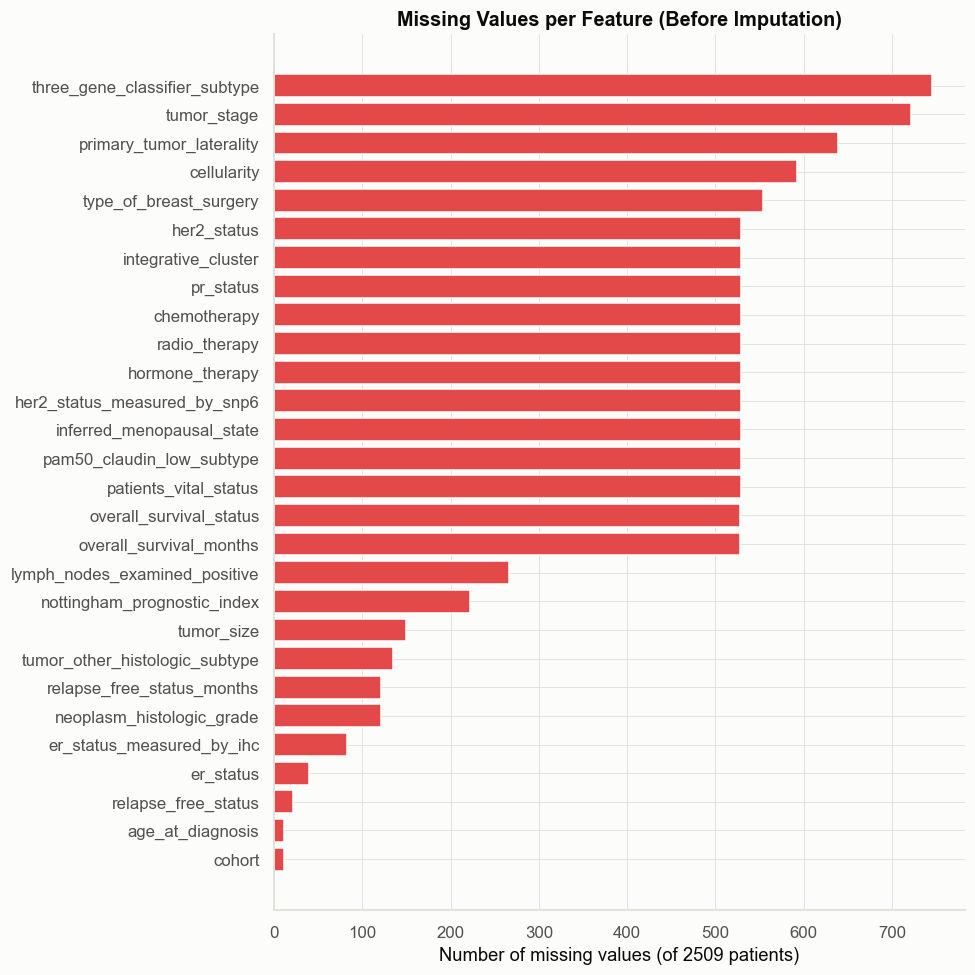

In [7]:
fig, ax = plt.subplots(figsize=(9, 9))
top_missing = miss_tbl[miss_tbl["n_missing"] > 0].sort_values("n_missing")
from src.visualization import CATEGORICAL
ax.barh(top_missing.index.astype(str), top_missing["n_missing"], color=CATEGORICAL[7])
ax.set_xlabel("Number of missing values (of 2509 patients)")
ax.set_title("Missing Values per Feature (Before Imputation)")
plt.tight_layout()
save_figure(fig, "02_missing_values_bar", subdir="02_data_exploration")
plt.show()


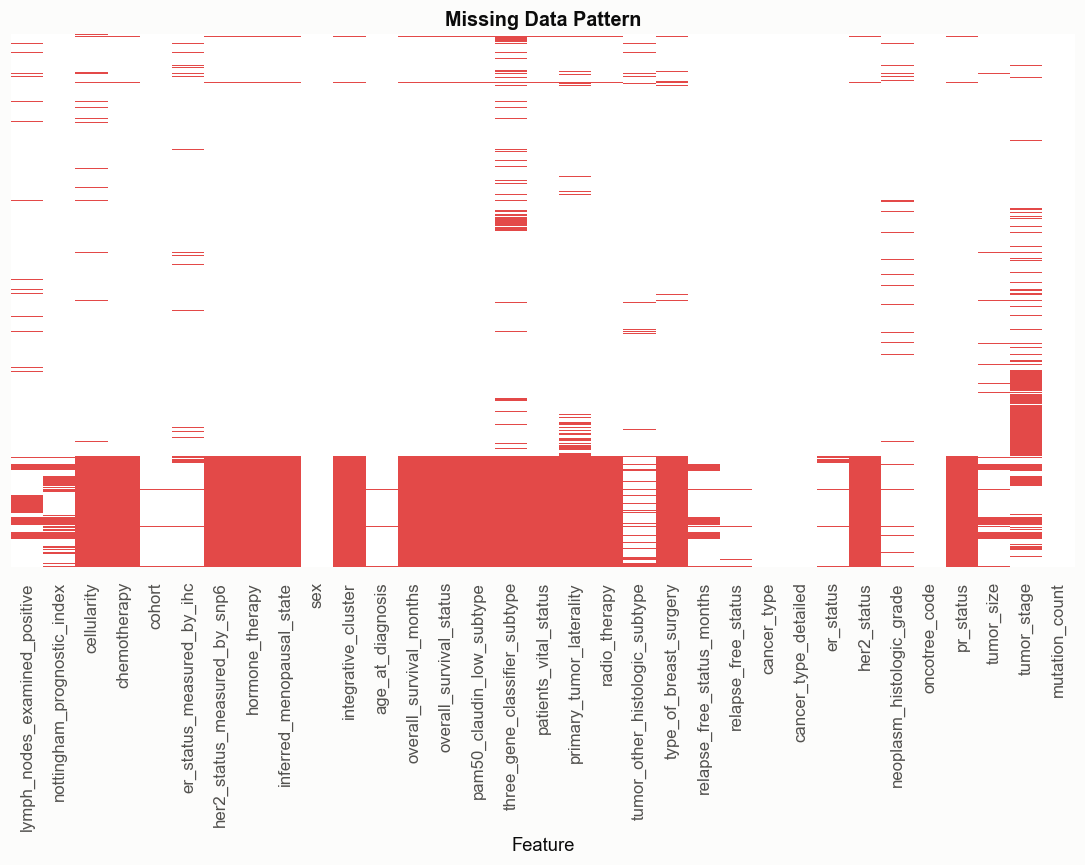

In [8]:
from src.visualization import plot_missingness_heatmap

fig, ax = plot_missingness_heatmap(raw.drop(columns=["patient_id"]))
plt.tight_layout()
save_figure(fig, "02_missingness_heatmap", subdir="02_data_exploration")
plt.show()


## 4. The modelling cohort and target variable

Following the paper, patients with a missing **Overall Survival Status** cannot contribute to the classification task and are dropped for modelling purposes (528 patients in the paper's account). We keep the raw cohort for descriptive EDA above, and switch to the *modelling* cohort from here on.

In [9]:
model_df = load_clinical(drop_missing_target=True)
print(f"Modelling cohort (Overall Survival Status known): {model_df.shape[0]} patients")
print(f"Paper reports 2509 - 528 = 1981 patients with known Overall Survival Status; we reproduce this exactly:", model_df.shape[0] == 1981)

target_counts = model_df[TARGET_COL].map({0: "Living", 1: "Deceased"}).value_counts()
print("\nOverall Survival Status distribution:")
print(target_counts)
print(f"Deceased proportion: {target_counts['Deceased'] / target_counts.sum():.1%}")


Modelling cohort (Overall Survival Status known): 1981 patients
Paper reports 2509 - 528 = 1981 patients with known Overall Survival Status; we reproduce this exactly: True

Overall Survival Status distribution:
overall_survival_status
Deceased    1144
Living       837
Name: count, dtype: int64
Deceased proportion: 57.7%


**Note on Fig. 1 of the paper.** The paper's Fig. 1 reports 1,330 Deceased + 677 Living = 2,007 patients (66.3% / 33.7%) *before* SMOTE, which is inconsistent with its own Table 1 (2509 - 528 missing = 1,981). Our reconstruction of `Overall Survival Status` from the cBioPortal `OS_STATUS` field reproduces the **Table 1** figure exactly (1,981 patients: 1,144 Deceased / 837 Living = 57.8% / 42.2%), which is the internally-consistent number. This discrepancy inside the published paper itself is discussed in Notebook 09.

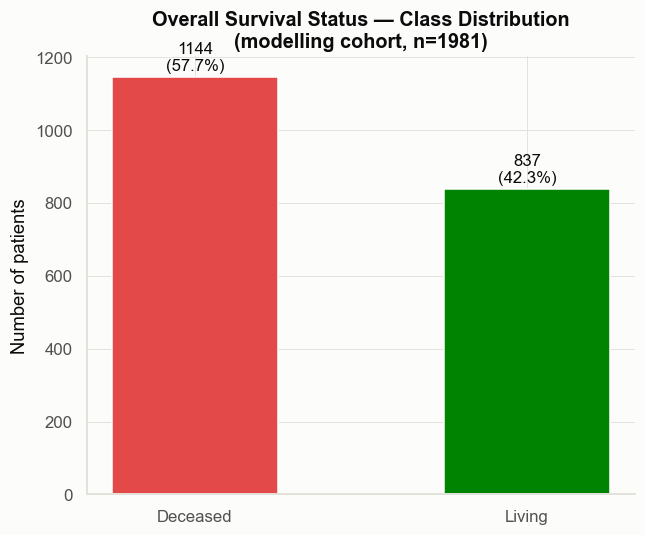

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
from src.visualization import CLASS_COLORS
colors = [CLASS_COLORS["Deceased"], CLASS_COLORS["Living"]]
bars = ax.bar(target_counts.index, target_counts.values, color=colors, width=0.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height()+10, f"{int(b.get_height())}\n({b.get_height()/target_counts.sum():.1%})",
            ha="center", va="bottom")
ax.set_ylabel("Number of patients")
ax.set_title("Overall Survival Status — Class Distribution\n(modelling cohort, n=1981)")
plt.tight_layout()
save_figure(fig, "02_target_class_distribution", subdir="02_data_exploration")
plt.show()


## 5. Cohort split by surgery type

In [11]:
groups = split_by_surgery(model_df)
for name, g in groups.items():
    dist = g[TARGET_COL].map({0: "Living", 1: "Deceased"}).value_counts()
    print(f"{name}: n={len(g)}  Deceased={dist.get('Deceased',0)} ({dist.get('Deceased',0)/len(g):.1%})  Living={dist.get('Living',0)} ({dist.get('Living',0)/len(g):.1%})")


Mastectomy: n=1170  Deceased=759 (64.9%)  Living=411 (35.1%)
BCS: n=785  Deceased=368 (46.9%)  Living=417 (53.1%)


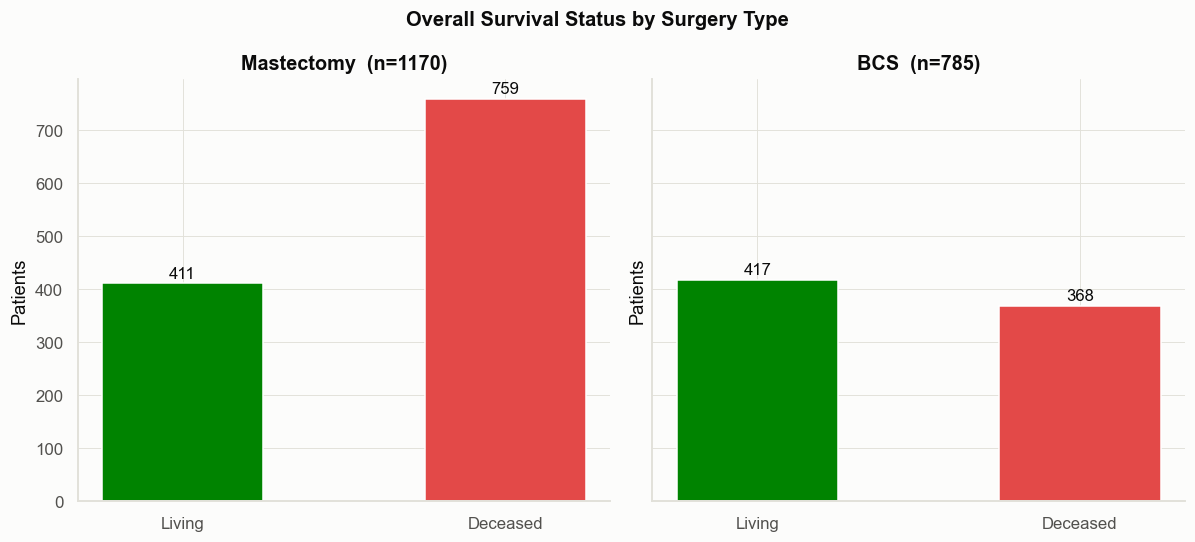

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, (name, g) in zip(axes, groups.items()):
    dist = g[TARGET_COL].map({0: "Living", 1: "Deceased"}).value_counts().reindex(["Living", "Deceased"])
    colors = [CLASS_COLORS["Living"], CLASS_COLORS["Deceased"]]
    bars = ax.bar(dist.index, dist.values, color=colors, width=0.5)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(int(b.get_height())), ha="center", va="bottom")
    ax.set_title(f"{name}  (n={len(g)})")
    ax.set_ylabel("Patients")
fig.suptitle("Overall Survival Status by Surgery Type", fontweight="bold")
plt.tight_layout()
save_figure(fig, "02_target_by_surgery", subdir="02_data_exploration")
plt.show()


**Interpretation.** The two surgical cohorts are of markedly different size (Mastectomy n≈1,170 vs. BCS n≈785) and, importantly, have *opposite* class balance: Mastectomy patients are majority Deceased, while BCS patients are closer to balanced / majority Living. This asymmetry is itself informative (Mastectomy is more often indicated for higher-risk disease) and is exactly why the paper trains and evaluates a **separate** model per surgery group rather than pooling them -- a design choice we preserve throughout.

## 6. Descriptive statistics — numerical features

In [13]:
from src.utils import NUMERIC_FEATURES

numeric_present = [c for c in NUMERIC_FEATURES if c in model_df.columns]
desc = model_df[numeric_present].describe().T
desc["missing"] = model_df[numeric_present].isna().sum()
desc.to_csv(PATHS.reports / "numeric_feature_descriptive_stats.csv")
desc


,count,mean,std,min,25%,50%,75%,max,missing
age_at_diagnosis,1981.0,61.086986,12.949710,21.93,51.420000,61.810000,70.600000,96.290000,0
lymph_nodes_examined_positive,1905.0,2.001050,4.079179,0.00,0.000000,0.000000,2.000000,45.000000,76
mutation_count,1981.0,6.993669,5.440772,0.00,3.922553,6.537589,9.152624,104.601416,0
nottingham_prognostic_index,1980.0,4.010960,1.162498,1.00,3.044000,4.041000,5.040000,6.360000,1
overall_survival_months,1981.0,125.244271,76.111772,0.00,60.866667,116.466667,185.133333,355.200000,0
relapse_free_status_months,1981.0,111.540451,77.326591,0.00,42.300000,102.066667,169.833333,351.000000,0
tumor_size,1955.0,26.275581,15.379858,1.00,17.000000,23.000000,30.000000,182.000000,26
tumor_stage,1466.0,1.736016,0.642541,0.00,1.000000,2.000000,2.000000,4.000000,515
neoplasm_histologic_grade,1893.0,2.414157,0.649158,1.00,2.000000,3.000000,3.000000,3.000000,88
cohort,1981.0,2.619384,1.232353,1.00,1.000000,3.000000,3.000000,5.000000,0


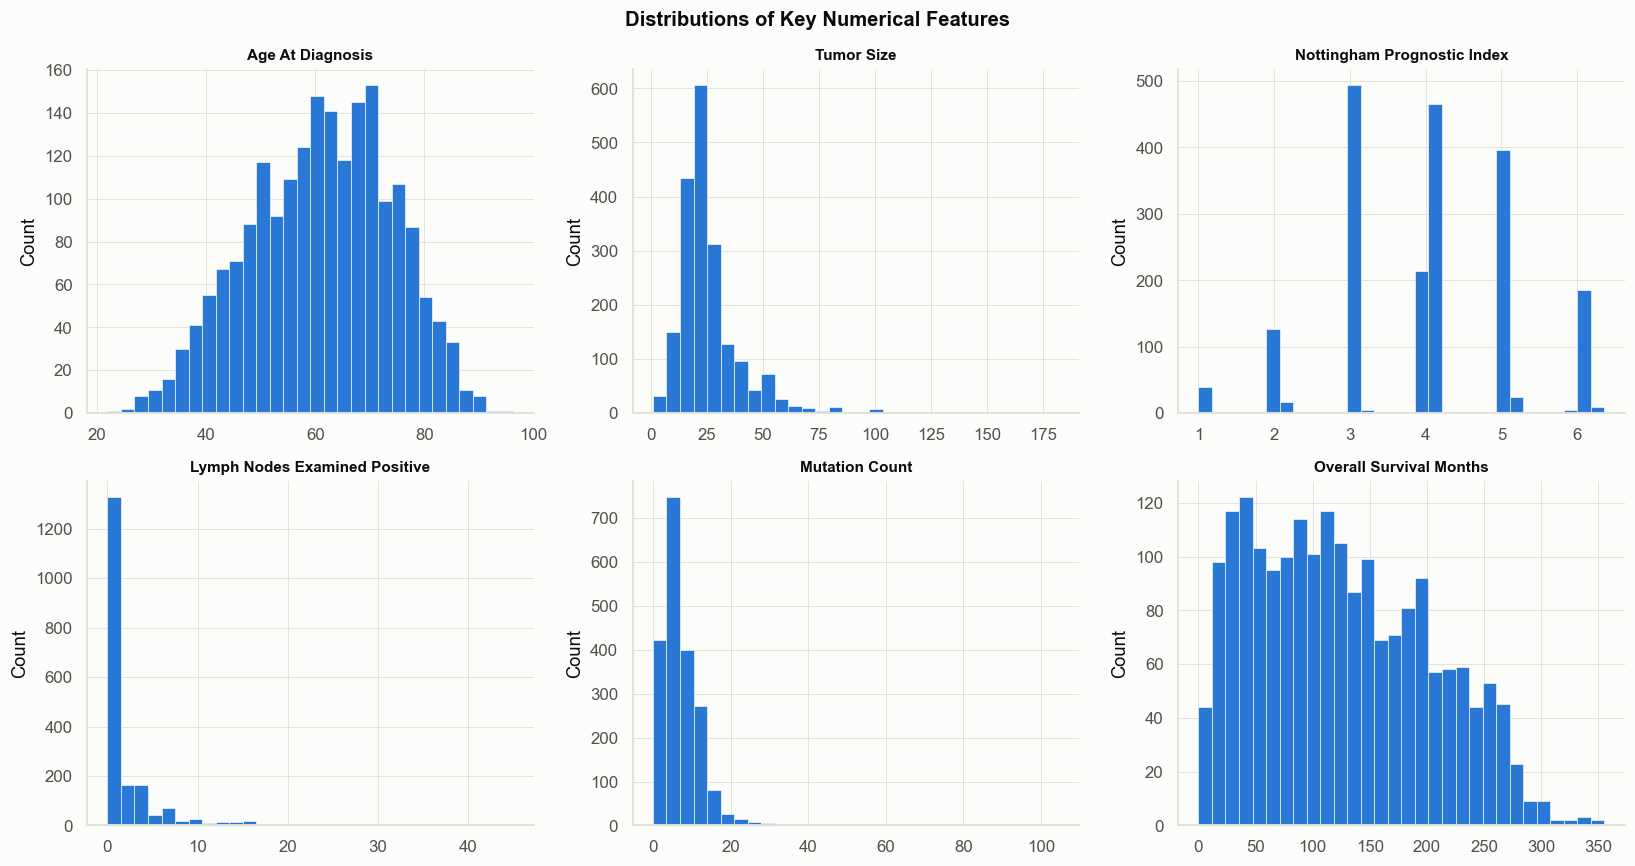

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_numeric = ["age_at_diagnosis", "tumor_size", "nottingham_prognostic_index",
               "lymph_nodes_examined_positive", "mutation_count", "overall_survival_months"]
from src.visualization import CATEGORICAL
for ax, col in zip(axes.ravel(), key_numeric):
    data = model_df[col].dropna()
    ax.hist(data, bins=30, color=CATEGORICAL[0], edgecolor="white", linewidth=0.4)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Count")
fig.suptitle("Distributions of Key Numerical Features", fontweight="bold")
plt.tight_layout()
save_figure(fig, "02_numeric_histograms", subdir="02_data_exploration")
plt.show()


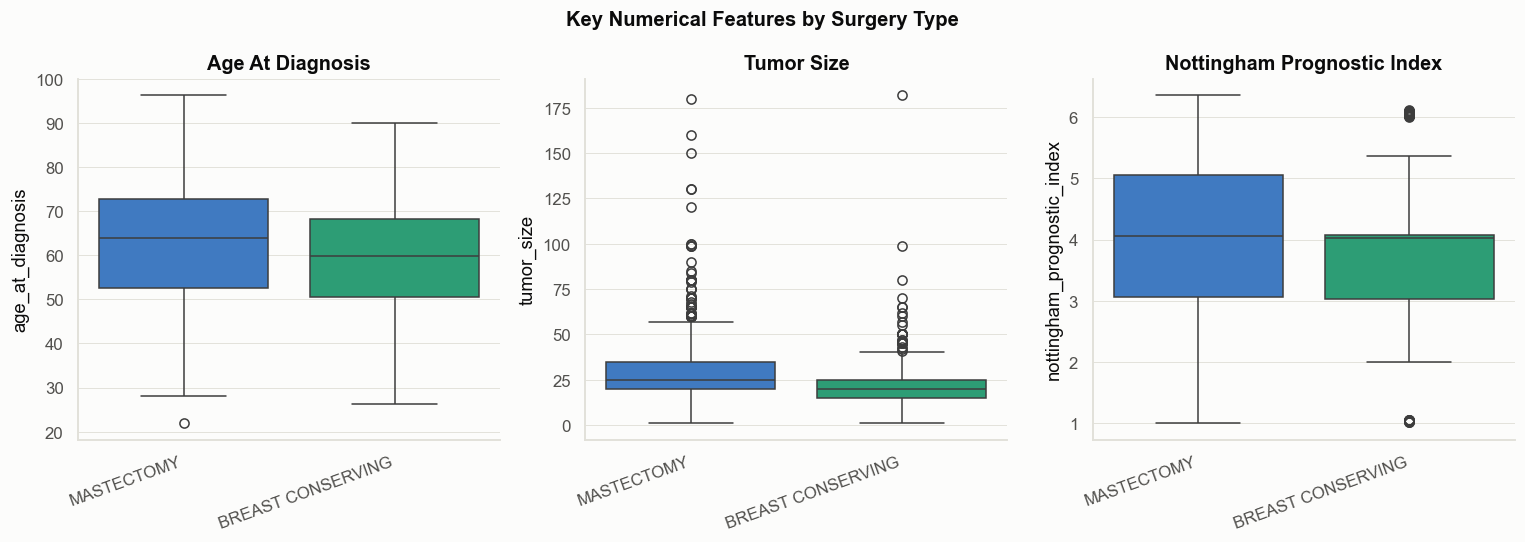

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
box_features = ["age_at_diagnosis", "tumor_size", "nottingham_prognostic_index"]
plot_df = model_df[box_features + [SURGERY_COL]].dropna(subset=[SURGERY_COL])
for ax, col in zip(axes, box_features):
    sns.boxplot(data=plot_df, x=SURGERY_COL, y=col, ax=ax, palette=[CATEGORICAL[0], CATEGORICAL[4]])
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.suptitle("Key Numerical Features by Surgery Type", fontweight="bold")
plt.tight_layout()
save_figure(fig, "02_boxplots_by_surgery", subdir="02_data_exploration")
plt.show()


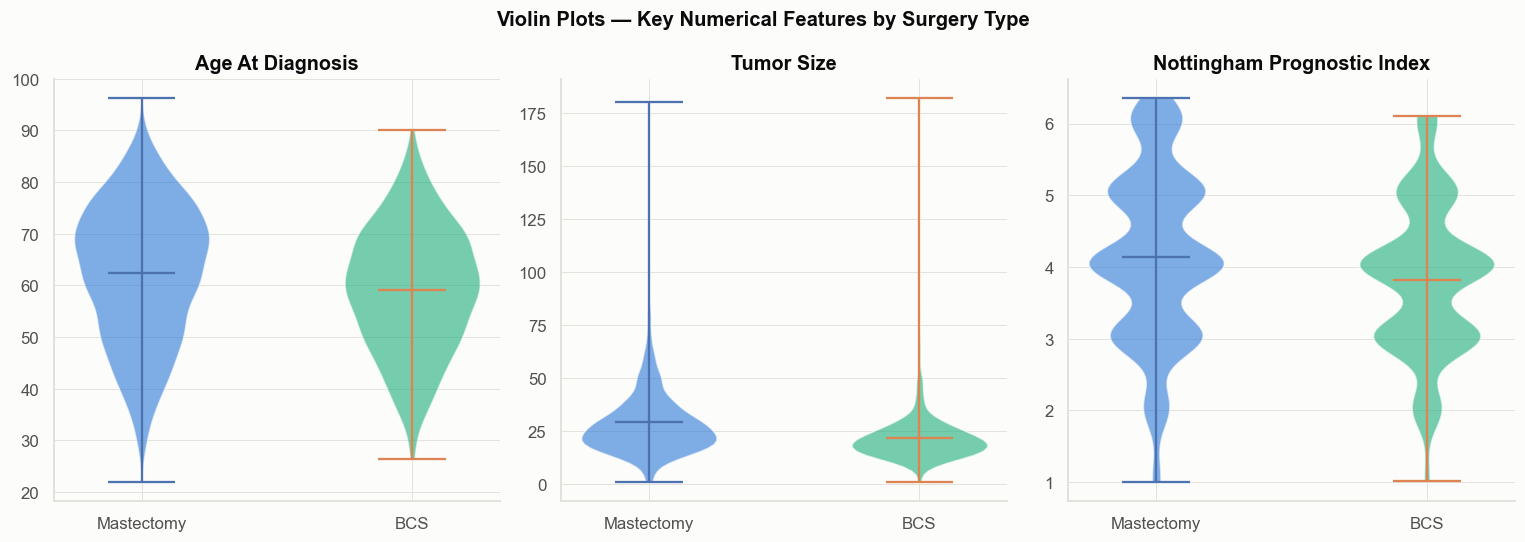

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, box_features):
    for grp, color in zip(["MASTECTOMY", "BREAST CONSERVING"], [CATEGORICAL[0], CATEGORICAL[4]]):
        subset = plot_df[plot_df[SURGERY_COL] == grp][col].dropna()
        parts = ax.violinplot(subset, positions=[0 if grp=="MASTECTOMY" else 1], showmeans=True)
        for pc in parts["bodies"]:
            pc.set_facecolor(color); pc.set_alpha(0.6)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Mastectomy", "BCS"])
    ax.set_title(col.replace("_", " ").title())
fig.suptitle("Violin Plots — Key Numerical Features by Surgery Type", fontweight="bold")
plt.tight_layout()
save_figure(fig, "02_violinplots_by_surgery", subdir="02_data_exploration")
plt.show()


## 7. Descriptive statistics — categorical / clinical-molecular features

In [17]:
from src.utils import CATEGORICAL_FEATURES

categorical_present = [c for c in CATEGORICAL_FEATURES if c in model_df.columns]
cat_summary_rows = []
for col in categorical_present:
    vc = model_df[col].value_counts(dropna=False)
    cat_summary_rows.append({
        "feature": col,
        "n_unique": model_df[col].nunique(dropna=True),
        "top_category": vc.index[0],
        "top_category_pct": round(100 * vc.iloc[0] / len(model_df), 1),
        "n_missing": int(model_df[col].isna().sum()),
    })
cat_summary = pd.DataFrame(cat_summary_rows).sort_values("n_unique", ascending=False)
cat_summary.to_csv(PATHS.reports / "categorical_feature_summary.csv", index=False)
cat_summary


,feature,n_unique,top_category,top_category_pct,n_missing
12,integrative_cluster,11,8,15.1,1
9,tumor_other_histologic_subtype,8,Ductal/NST,75.3,44
14,oncotree_code,8,IDC,77.6,0
1,cancer_type_detailed,8,Breast Invasive Ductal Carcinoma,77.6,0
4,pam50_claudin_low_subtype,7,LumA,35.3,1
18,three_gene_classifier_subtype,4,ER+/HER2- Low Prolif,32.3,217
7,her2_status_measured_by_snp6,4,NEUTRAL,72.5,1
2,cellularity,3,High,48.7,64
19,patients_vital_status,3,Living,42.3,1
11,inferred_menopausal_state,2,Post,78.5,1


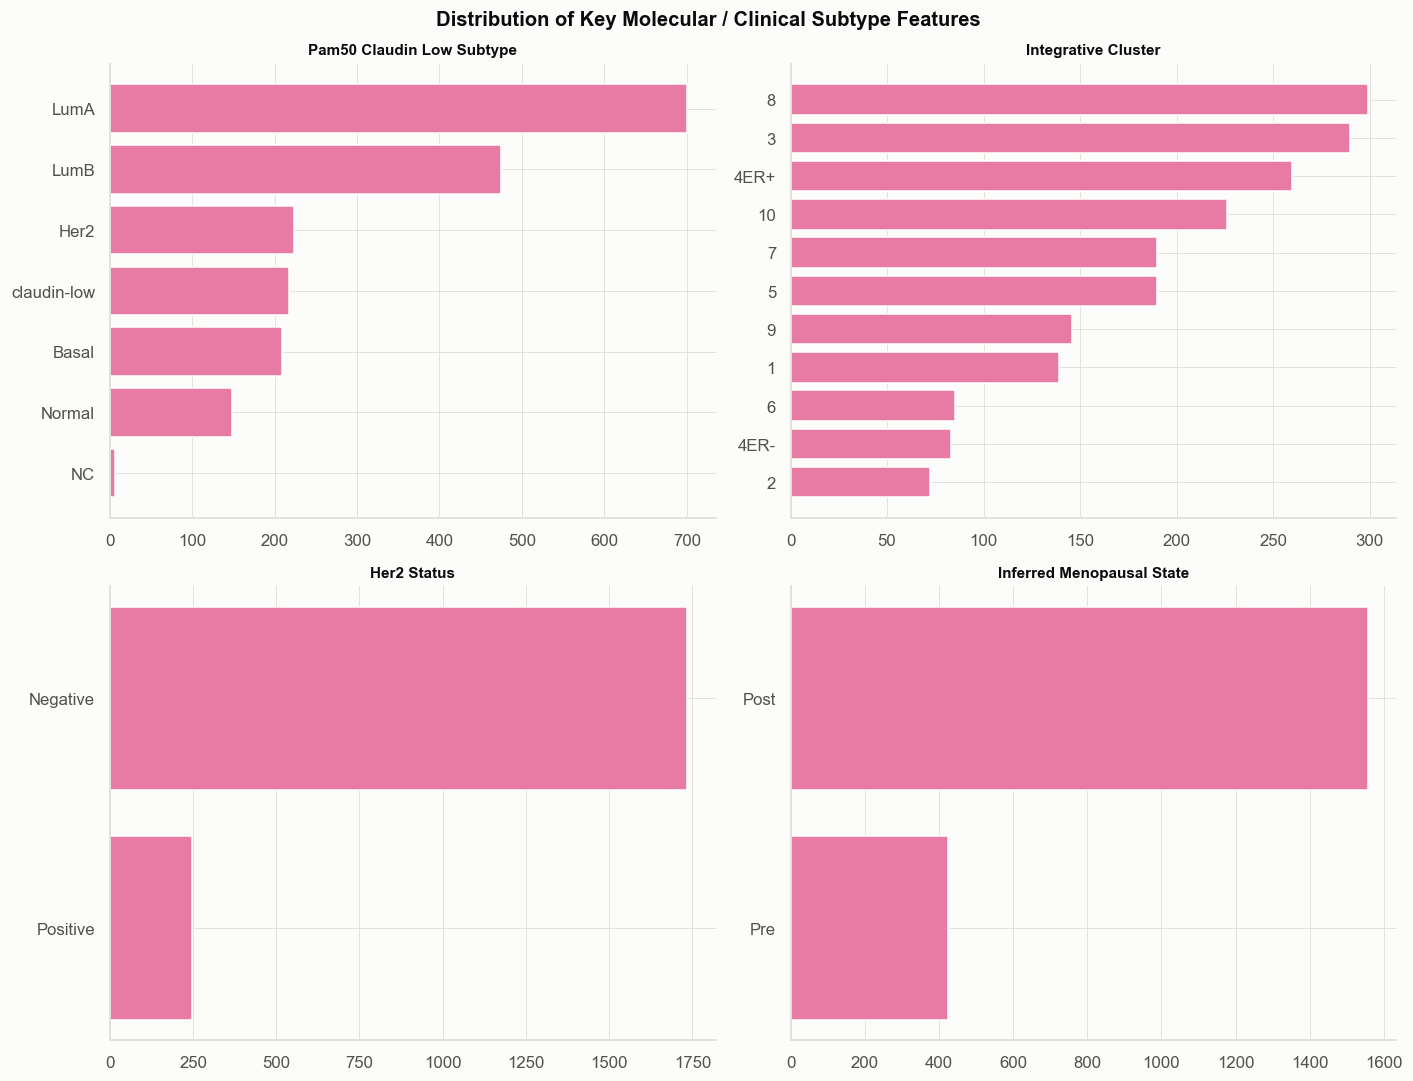

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
mol_features = ["pam50_claudin_low_subtype", "integrative_cluster", "her2_status", "inferred_menopausal_state"]
for ax, col in zip(axes.ravel(), mol_features):
    vc = model_df[col].value_counts().sort_values(ascending=True)
    ax.barh(vc.index.astype(str), vc.values, color=CATEGORICAL[2])
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
fig.suptitle("Distribution of Key Molecular / Clinical Subtype Features", fontweight="bold")
plt.tight_layout()
save_figure(fig, "02_categorical_distributions", subdir="02_data_exploration")
plt.show()


**Interpretation.** PAM50+Claudin-low subtype and Integrative Cluster -- the two richest molecular classifiers in METABRIC -- show the expected long-tailed distribution over 5-10 categories, consistent with known breast cancer subtype prevalence (Luminal A/B dominant, Basal-like and HER2-enriched minority groups). HER2 status is strongly imbalanced toward Negative, matching the ~15-20% HER2-positive prevalence reported in the wider breast-cancer literature.

## 8. Correlation analysis (numerical features)

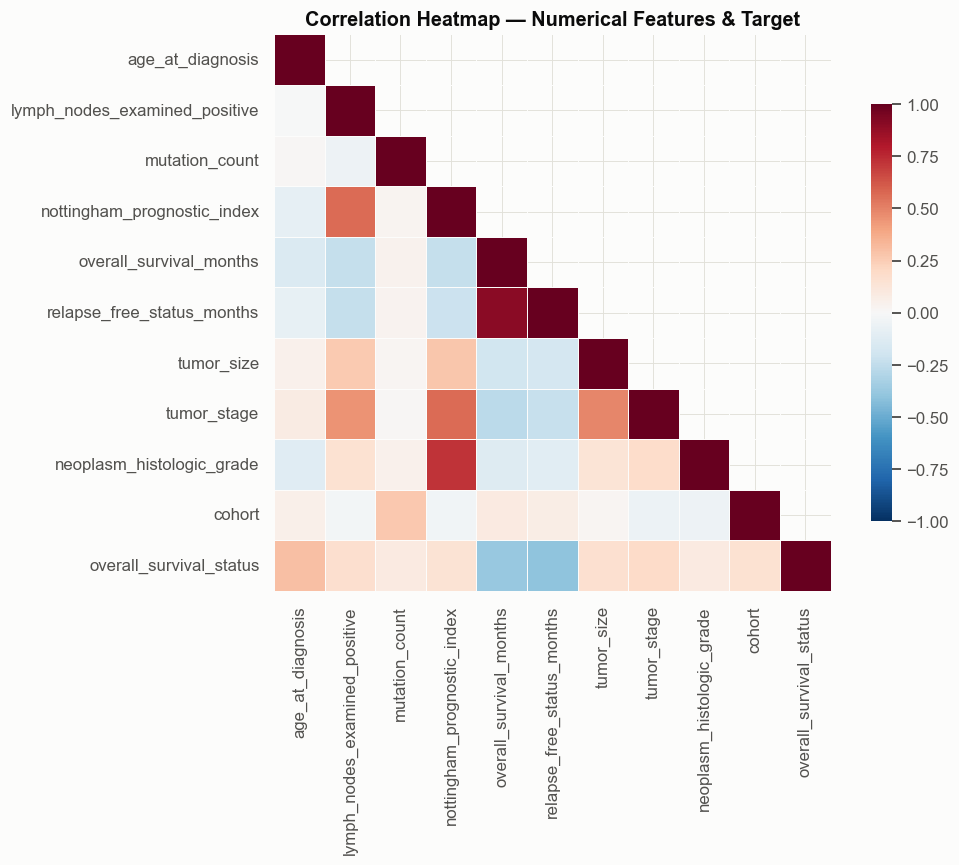

In [19]:
from src.visualization import plot_correlation_heatmap

corr_cols = numeric_present + [TARGET_COL]
corr = model_df[corr_cols].corr(numeric_only=True)
fig, ax = plot_correlation_heatmap(corr, figsize=(10, 8), title="Correlation Heatmap — Numerical Features & Target")
plt.tight_layout()
save_figure(fig, "02_correlation_heatmap", subdir="02_data_exploration")
plt.show()


In [20]:
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print("Correlation of each numeric feature with Overall Survival Status (point-biserial via Pearson r):")
target_corr.to_frame("pearson_r").to_csv(PATHS.reports / "target_correlations.csv")
target_corr


Correlation of each numeric feature with Overall Survival Status (point-biserial via Pearson r):


relapse_free_status_months      -0.404618
overall_survival_months         -0.381050
age_at_diagnosis                 0.303115
tumor_stage                      0.193166
lymph_nodes_examined_positive    0.164237
tumor_size                       0.162816
cohort                           0.154633
nottingham_prognostic_index      0.142115
mutation_count                   0.092109
neoplasm_histologic_grade        0.086937
Name: overall_survival_status, dtype: float64

**Interpretation.** `overall_survival_months` and `relapse_free_status_months` are, unsurprisingly, the numeric features most correlated with the survival target -- shorter observed survival/relapse-free time is associated with the Deceased class by construction of the endpoint (administrative/informative censoring effect). `nottingham_prognostic_index` and `age_at_diagnosis` show the expected positive association with mortality, consistent with their established clinical role as prognostic factors. This correlation structure foreshadows the SHAP findings in Notebook 07 and the data-leakage discussion in Notebook 09.

## 9. Discussion & Conclusion

- The reconstructed METABRIC cohort matches the paper's reported dimensions exactly (2,509 x 34 raw; 1,981 modelling patients after removing missing-target rows), confirming that merging `data_clinical_patient.txt` + `data_clinical_sample.txt` on Patient ID is a faithful substitute for the Kaggle CSV the paper used.
- Missingness is substantial and concentrated in molecular/treatment fields (Chemotherapy, Hormone Therapy, HER2 status, Integrative Cluster, etc.), motivating the KNN/mode imputation strategy examined in Notebook 03.
- The two surgical cohorts differ in size and in class balance, justifying the paper's per-group modelling strategy, which we preserve throughout.
- A minor but important discrepancy between the paper's Fig. 1 and Table 1 patient counts is documented and resolved in favour of the internally-consistent Table 1 figure; this is revisited quantitatively in Notebook 09.

**Next:** Notebook 03 performs missing-value imputation, its statistical validation, outlier detection, encoding, scaling, and the surgery-vs-survival logistic regression significance test.